In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import hstack, csr_matrix
from textblob import TextBlob
from collections import Counter
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [96]:
train = pd.read_csv(r'C:\Users\Administrator\Downloads\ai-camp-2-02-sa\train (1).csv')
test = pd.read_csv(r'C:\Users\Administrator\Downloads\ai-camp-2-02-sa\test (1).csv')
sub = pd.read_csv(r'C:\Users\Administrator\Downloads\ai-camp-2-02-sa\sol_true.csv')

In [97]:
train.head()

,ID,sentence,label
0,8965,No other cashier seemed all too eager to exerc...,negative
1,5936,An under regulated business model which is tak...,negative
2,10655,"We don't have them, so we wanted to call a pro...",neutral
3,3328,"WOW, this place was so honest!",positive
4,9691,It's scarry out there when most people take a...,negative


In [98]:
train.shape

(8798, 3)

In [99]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8798 entries, 0 to 8797
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ID        8798 non-null   int64 
 1   sentence  8798 non-null   object
 2   label     8798 non-null   object
dtypes: int64(1), object(2)
memory usage: 206.3+ KB


In [100]:
train.isna().sum()

ID          0
sentence    0
label       0
dtype: int64

In [101]:
train.duplicated().sum()

0

<Axes: xlabel='label', ylabel='count'>

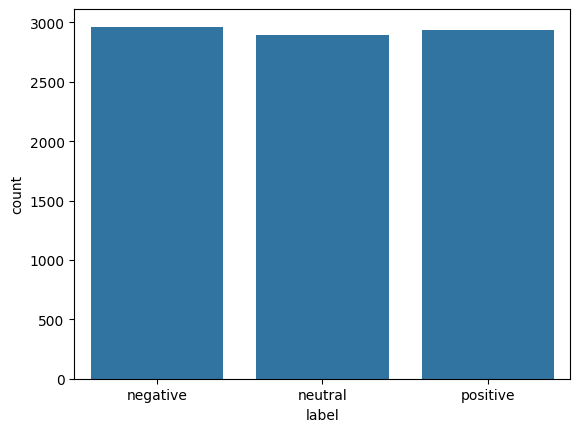

In [102]:
sns.countplot(x='label', data=train)

In [103]:
all_words = " ".join(train['sentence']).lower().split()
common_words = Counter(all_words).most_common(20)
common_words

[('the', 5647),
 ('and', 3620),
 ('a', 3519),
 ('i', 3405),
 ('to', 3266),
 ('was', 1887),
 ('of', 1849),
 ('it', 1476),
 ('for', 1448),
 ('in', 1433),
 ('is', 1296),
 ('my', 1207),
 ('that', 1138),
 ('we', 1080),
 ('this', 922),
 ('you', 859),
 ('with', 844),
 ('they', 830),
 ('on', 823),
 ('.', 797)]

In [104]:
for label in train['label'].unique():
    text = " ".join(train[train['label'] == label]['sentence']).lower().split()
    common = Counter(text).most_common(10)
    print(f"\nTop mots pour {label}:")
    print(common)


Top mots pour negative:
[('the', 2115), ('a', 1315), ('to', 1226), ('and', 1186), ('i', 1121), ('of', 738), ('was', 725), ('it', 643), ('is', 508), ('that', 506)]

Top mots pour neutral:
[('the', 1535), ('i', 1209), ('a', 1094), ('and', 1046), ('to', 1023), ('for', 501), ('of', 493), ('in', 468), ('my', 444), ('was', 433)]

Top mots pour positive:
[('the', 1997), ('and', 1388), ('a', 1110), ('i', 1075), ('to', 1017), ('was', 729), ('of', 618), ('it', 492), ('is', 480), ('in', 466)]


In [105]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)          
    text = re.sub(r"[^a-zA-Z0-9\s.,!?']", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    return text

train['clean_sentence'] = train['sentence'].apply(clean_text)
test['clean_sentence']  = test['sentence'].apply(clean_text)



In [106]:
def extract_features(df, col='sentence'):
   
    df['length']       = df[col].apply(len)
    df['word_count']   = df[col].apply(lambda x: len(x.split()))
    df['avg_word_len'] = df[col].apply(lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0)
    df['exclamation']  = df[col].apply(lambda x: x.count('!'))
    df['question']     = df[col].apply(lambda x: x.count('?'))
    df['uppercase']    = df[col].apply(lambda x: sum(1 for c in x if c.isupper()))
    df['unique_words'] = df[col].apply(lambda x: len(set(x.split())))

    return df

train = extract_features(train)
test  = extract_features(test)

In [107]:

vader = SentimentIntensityAnalyzer()
def extract_features_vader(df, col='sentence'):
    
    df['vader_pos']  = df[col].apply(lambda x: vader.polarity_scores(x)['pos'])
    df['vader_neg']  = df[col].apply(lambda x: vader.polarity_scores(x)['neg'])
    df['vader_neu']  = df[col].apply(lambda x: vader.polarity_scores(x)['neu'])
    df['vader_comp'] = df[col].apply(lambda x: vader.polarity_scores(x)['compound'])
    return df

train = extract_features_vader(train)
test  = extract_features_vader(test)

In [108]:
def extract_features_textblob(df, col='sentence'):
    df['polarity']      = df[col].apply(lambda x: TextBlob(x).sentiment.polarity)
    df['subjectivity']  = df[col].apply(lambda x: TextBlob(x).sentiment.subjectivity)
    return df
train = extract_features_textblob(train)
test  = extract_features_textblob(test)

In [109]:
train.columns

Index(['ID', 'sentence', 'label', 'clean_sentence', 'length', 'word_count',
       'avg_word_len', 'exclamation', 'question', 'uppercase', 'unique_words',
       'vader_pos', 'vader_neg', 'vader_neu', 'vader_comp', 'polarity',
       'subjectivity'],
      dtype='object')

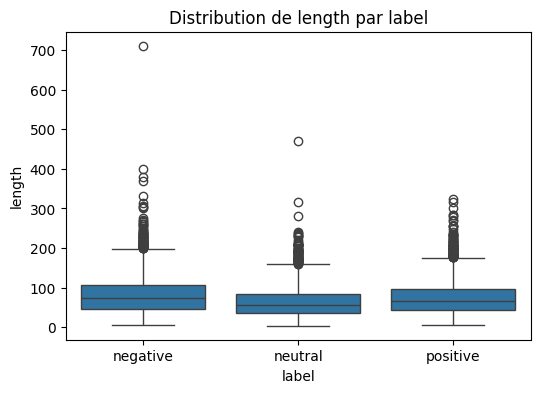

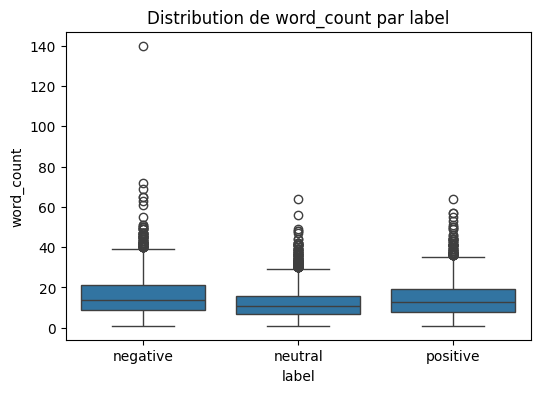

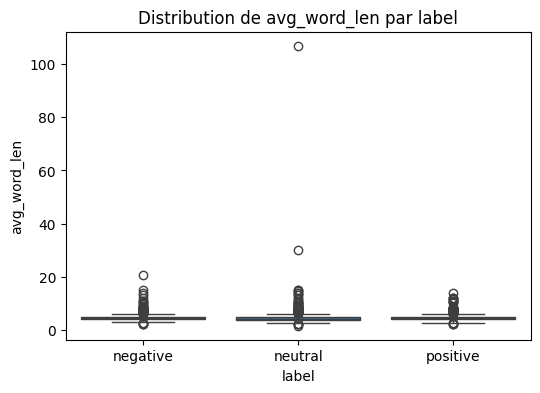

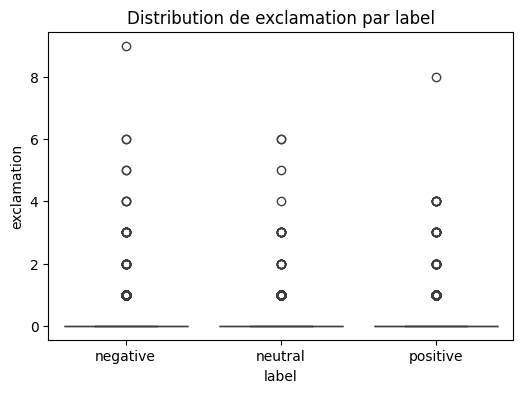

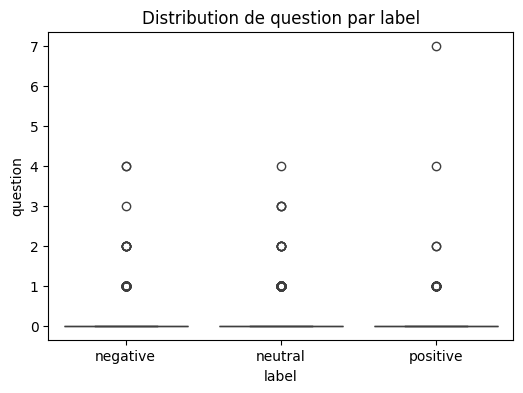

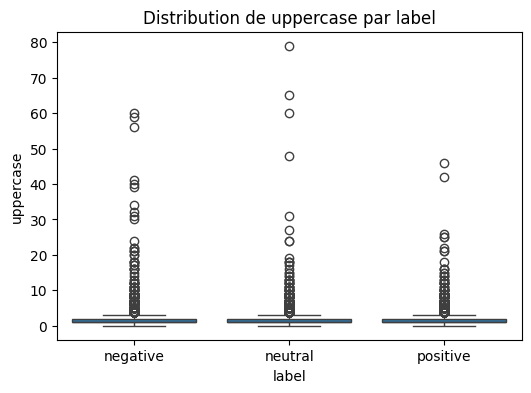

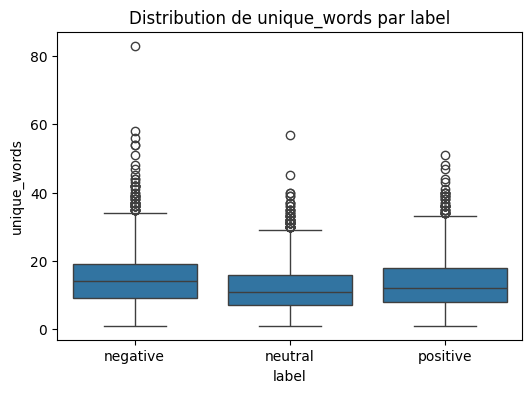

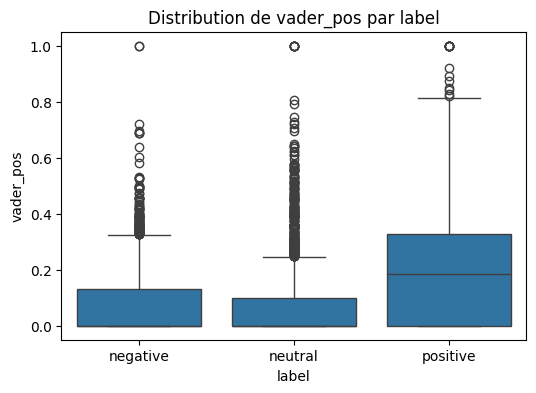

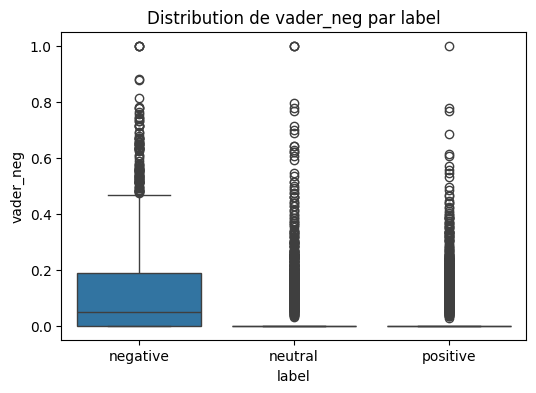

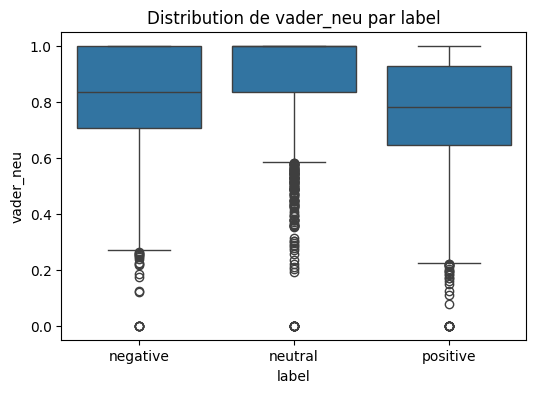

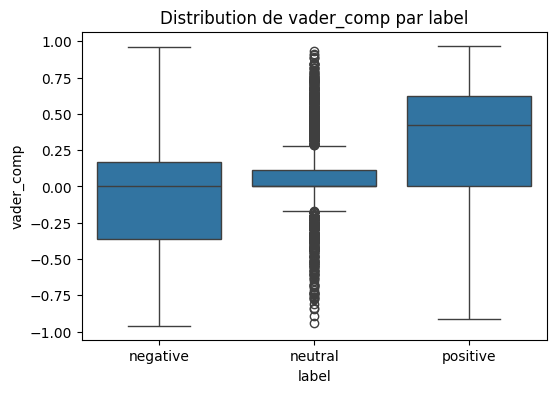

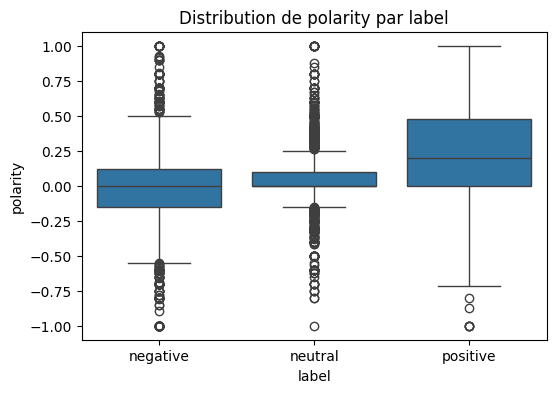

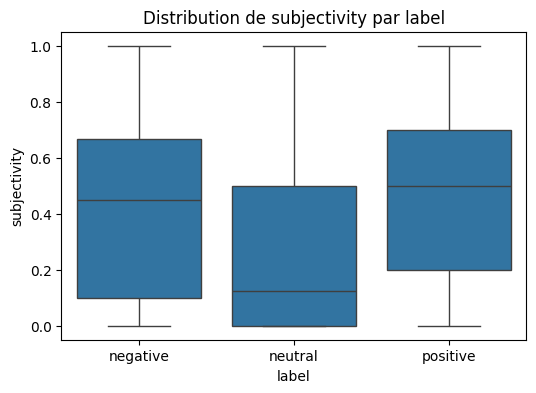

In [110]:
for col in train.columns:
    if col not in ['ID', 'sentence', 'clean_sentence', 'label']:
        plt.figure(figsize=(6,4))
        sns.boxplot(x='label', y=col, data=train)
        plt.title(f"Distribution de {col} par label")
        plt.show()

In [111]:
X_train = train['clean_sentence']
X_test  = test['clean_sentence']
y       = train['label']

In [112]:
num_features = ['length','word_count','avg_word_len','exclamation','question',
                'uppercase','unique_words','vader_pos','vader_neg','vader_neu',
                'vader_comp','polarity','subjectivity']

scaler      = MinMaxScaler()
X_train_num = csr_matrix(scaler.fit_transform(train[num_features]))
X_test_num  = csr_matrix(scaler.transform(test[num_features]))

In [113]:
tfidf_word = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 3),
    min_df=1,           
    max_df=0.95,
    sublinear_tf=True
)
X_train_word = tfidf_word.fit_transform(X_train)
X_test_word  = tfidf_word.transform(X_test)

tfidf_char = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=15000,
    sublinear_tf=True,
    min_df=1            
)
X_train_char = tfidf_char.fit_transform(X_train)
X_test_char  = tfidf_char.transform(X_test)

X_train_final = hstack([X_train_word, X_train_char, X_train_num])
X_test_final  = hstack([X_test_word,  X_test_char,  X_test_num])

In [116]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_final, y)
y_pred = lr.predict(X_test_final)
acc=accuracy_score(sub['label'], y_pred)
acc

0.6422727272727272